In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

# Surface a failed install here, rather than as a confusing ModuleNotFoundError
# in the import cell below.
import importlib.metadata as md
assert md.version("nucleus-cdk") == "0.5.0rc2", f"got {md.version('nucleus-cdk')}"

Analyze time-series fluorescence data from PURE experiments.

## Setup 

In [2]:
%load_ext autoreload
%autoreload 2
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.analysis.cytosol import platereader as pr

# Set up plotting
pr.plot_setup()

In [3]:
!pwd

/Users/sharonnewman/Documents/general/nucleus-devnote-archive-1/devnotes/2026-newman-cytosol-landscape/experiments/20260506-discoveryplate-aria-r3


In [4]:
import os
# print(os.path)

## Load Data

In [5]:
# labcraft_platemap = pd.read_csv("experiment_setup_v2_b/labcraft_results/DP-R3b-20260518_112845/concentration_key.csv")
labcraft_platemap = pd.read_csv("data/concentration_key_corrected_mg2000_24p602_mg250_14p862.csv") #I believe Mg 2000 mM was added second...that means with the larger droplet size. Yikes :'(
labcraft_platemap = labcraft_platemap.rename(columns={'Well ID': 'Well'})
labcraft_platemap = labcraft_platemap.set_index("Well")
labcraft_platemap = labcraft_platemap.fillna(0)

samples = pd.read_csv("data/samples_titration_FINAL.csv", index_col="Well")

In [6]:
labcraft_platemap

,actual_final_volume_nL,[ATP]_mM,[Creatine phosphate]_mM,[DNA]_nM,[GTP]_mM,[Magnesium acetate]_mM,[PolyP]_mM,[PPK]_uM,[tRNA]_ug/ul,Water_--
Well,,,,,,,,,,
E6,8927.99,2.13,25.31,2.27,1.85,22.46,31.96,3.06,1.41,0.01
E7,9623.31,0.86,16.26,2.11,3.83,47.56,13.95,0.47,1.95,0.11
E8,8985.95,0.49,17.41,2.25,3.59,8.37,33.62,2.03,1.83,0.02
E9,10713.30,0.00,12.17,1.89,0.00,15.86,0.00,0.00,0.16,0.34
E10,9954.28,0.00,0.00,2.04,0.00,0.00,16.86,1.37,0.86,0.24
...,...,...,...,...,...,...,...,...,...,...
L14,9254.36,0.07,27.24,2.19,0.64,0.00,30.83,2.96,0.73,0.10
L15,9033.33,3.93,3.85,2.24,2.04,39.77,24.15,2.27,2.31,0.01
L16,9924.64,1.08,6.13,2.04,0.27,0.00,25.37,0.00,0.00,0.25


In [7]:
# Normalize column headers: '[ATP]_mM' -> '[ATP] mM'
labcraft_platemap.columns = [str(c).replace("_", " ") for c in labcraft_platemap.columns]

labcraft_platemap.columns

Index(['actual final volume nL', '[ATP] mM', '[Creatine phosphate] mM',
       '[DNA] nM', '[GTP] mM', '[Magnesium acetate] mM', '[PolyP] mM',
       '[PPK] uM', '[tRNA] ug/ul', 'Water --'],
      dtype='object')

In [8]:

# Add base concentration back to titration volumes
from cdk_naming import (
    normalize_reagent_name,
    split_concentration_column_name,
)

base_mm = pd.read_csv(
    "data/base_master_mix_w_smix.csv", index_col="reagent"
)

# normalized reagent key -> (base_conc, unit) lookup
base_lookup = {
    normalize_reagent_name(idx): (row["base_conc_fold"], row["unit"])
    for idx, row in base_mm.iterrows()
}
vol_base_added = 6420

def _reagent_from_col(col):
    """Pull the reagent token from headers like
    '[Magnesium acetate] (mM)', '[ATP]_mM', '[tRNA] ug/ul'.
    """
    # s = str(col).replace("_", " ")
    parts = split_concentration_column_name(col)
    return parts[0] if parts else s  # parts[0] keeps wrappers; normalize strips them

for col in labcraft_platemap.select_dtypes("number").columns:
    key = normalize_reagent_name(_reagent_from_col(col))
    if key in base_lookup:
        base_conc, unit = base_lookup[key]
        labcraft_platemap[col] += base_conc * vol_base_added / labcraft_platemap['actual final volume nL']
        print(f"Added base_conc for '{col}': +{base_conc} {unit}")
    else:
        print(f"  (no base_conc match for '{col}' → key={key!r})")

  (no base_conc match for 'actual final volume nL' → key='actualfinalvolume')
Added base_conc for '[ATP] mM': +3.12 mM
Added base_conc for '[Creatine phosphate] mM': +31.2 mM
  (no base_conc match for '[DNA] nM' → key='dna')
Added base_conc for '[GTP] mM': +3.12 mM
Added base_conc for '[Magnesium acetate] mM': +12.48 mM
  (no base_conc match for '[PolyP] mM' → key='polyp')
  (no base_conc match for '[PPK] uM' → key='ppk')
Added base_conc for '[tRNA] ug/ul': +3.9 ug/ul
  (no base_conc match for 'Water --' → key='water')


In [9]:
labcraft_platemap

,actual final volume nL,[ATP] mM,[Creatine phosphate] mM,[DNA] nM,[GTP] mM,[Magnesium acetate] mM,[PolyP] mM,[PPK] uM,[tRNA] ug/ul,Water --
Well,,,,,,,,,,
E6,8927.99,4.37,47.75,2.27,4.09,31.43,31.96,3.06,4.22,0.01
E7,9623.31,2.94,37.07,2.11,5.92,55.89,13.95,0.47,4.56,0.11
E8,8985.95,2.72,39.70,2.25,5.82,17.29,33.62,2.03,4.62,0.02
E9,10713.30,1.87,30.87,1.89,1.87,23.34,0.00,0.00,2.50,0.34
E10,9954.28,2.01,20.12,2.04,2.01,8.05,16.86,1.37,3.37,0.24
...,...,...,...,...,...,...,...,...,...,...
L14,9254.36,2.23,48.88,2.19,2.81,8.66,30.83,2.96,3.44,0.10
L15,9033.33,6.14,26.02,2.24,4.26,48.64,24.15,2.27,5.08,0.01
L16,9924.64,3.10,26.31,2.04,2.28,8.07,25.37,0.00,2.52,0.25


In [10]:
FACTOR_COLS = labcraft_platemap.columns[1:-1]
# FACTOR_COLS = ['[ATP] mM', '[Creatine phosphate] mM', '[GTP] mM',
#        '[Magnesium acetate] mM', '[PolyP] mM', '[PPK] uM', '[tRNA] ug/ul']
# FACTOR_COLS = ['[ATP]_mM', '[Creatine phosphate]_mM', '[GTP]_mM',
#        '[Magnesium acetate]_mM', '[PolyP]_mM', '[PPK]_uM', '[tRNA]_ug/ul']

In [11]:
# Overwrite common concentration columns in samples with labcraft_platemap values
# Use .update() so only matching well_ids are overwritten (no NaNs for missing wells)
common_cols = labcraft_platemap.columns.intersection(samples.columns).tolist()
samples.update(labcraft_platemap[common_cols])
print(f"Updated {len(common_cols)} columns in samples from labcraft_platemap: {common_cols}")
samples

Updated 8 columns in samples from labcraft_platemap: ['[ATP] mM', '[Creatine phosphate] mM', '[DNA] nM', '[GTP] mM', '[Magnesium acetate] mM', '[PolyP] mM', '[PPK] uM', '[tRNA] ug/ul']


,Generator,Type,Name,[tRNA] ug/ul,[Magnesium acetate] mM,[Creatine phosphate] mM,[ATP] mM,[GTP] mM,[PPK] uM,[PolyP] mM,...,[PPK] uM conc_to_add,[PPK] uM vol_to_pipette_ul,[PolyP] mM conc_to_add,[PolyP] mM vol_to_pipette_ul,[DNA] nM conc_to_add,[DNA] nM vol_to_pipette_ul,base_master_mix_vol_to_add_ul,total_titration_vol_to_add_ul,buffer_vol_to_add_ul,total_vol_check_ul
Well,,,,,,,,,,,,,,,,,,,,,
H13,lhs,Sample,0,4.68,9.39,33.16,5.93,4.90,2.81,22.57,...,3.61,0.63,36.41,0.73,3.00,0.50,6.45,3.41,0.14,10.00
H14,lhs,Sample,0,4.68,9.39,33.16,5.93,4.90,2.81,22.57,...,3.61,0.63,36.41,0.73,3.00,0.50,6.45,3.41,0.14,10.00
G18,lhs,Sample,1,4.55,32.14,28.99,2.29,6.19,2.45,18.03,...,3.41,0.60,30.74,0.61,3.00,0.50,6.45,3.02,0.53,10.00
H8,lhs,Sample,1,4.55,32.14,28.99,2.29,6.19,2.45,18.03,...,3.41,0.60,30.74,0.61,3.00,0.50,6.45,3.02,0.53,10.00
E6,lhs,Sample,2,4.22,31.43,47.75,4.37,4.09,3.06,31.96,...,4.01,0.70,50.16,1.00,3.00,0.50,6.45,3.48,0.07,10.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
M13,manual,Control,manual_noDNA,3.50,8.00,20.00,2.00,2.00,0.00,0.00,...,0.00,0.00,0.00,0.00,3.00,0.50,6.45,0.79,2.76,10.00
M14,manual,Control,manual_noDNA,3.50,8.00,20.00,2.00,2.00,0.00,0.00,...,0.00,0.00,0.00,0.00,3.00,0.50,6.45,0.79,2.76,10.00
M15,manual,Control,manual_noDNA,3.50,8.00,20.00,2.00,2.00,0.00,0.00,...,0.00,0.00,0.00,0.00,3.00,0.50,6.45,0.79,2.76,10.00


In [12]:
samples.Name.unique()

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', 'ges_r3_01', 'ges_r3_02',
       'ges_r3_03', 'ges_r3_04', 'ges_r3_05', 'ges_r3_06', 'ges_r3_07',
       'ges_r3_08', 'ges_r3_09', 'ges_r3_10', 'ges_r3_11', 'ges_r3_12',
       'ges_r3_13', 'ges_r3_14', 'ges_r3_15', 'ges_r3_16', 'ges_r3_17',
       'ges_r3_18', 'ges_r3_19', 'ges_r3_20', 'ges_r3_21', 'ges_r3_22',
       'ges_r3_23', 'ges_r3_24', 'ges_r3_25', 'ges_r3_26', 'ges_r3_27',
       'ges_r3_28', 'ges_r3_29', 'labcraft_PPK', 'labcraft_ctrl',
       'manual_ctrl', 'Fluorescein', 'manual_noDNA'], dtype=object)

In [13]:
samples.to_csv("data/samples_final.csv")
samples.head()


,Generator,Type,Name,[tRNA] ug/ul,[Magnesium acetate] mM,[Creatine phosphate] mM,[ATP] mM,[GTP] mM,[PPK] uM,[PolyP] mM,...,[PPK] uM conc_to_add,[PPK] uM vol_to_pipette_ul,[PolyP] mM conc_to_add,[PolyP] mM vol_to_pipette_ul,[DNA] nM conc_to_add,[DNA] nM vol_to_pipette_ul,base_master_mix_vol_to_add_ul,total_titration_vol_to_add_ul,buffer_vol_to_add_ul,total_vol_check_ul
Well,,,,,,,,,,,,,,,,,,,,,
H13,lhs,Sample,0,4.68,9.39,33.16,5.93,4.90,2.81,22.57,...,3.61,0.63,36.41,0.73,3.00,0.50,6.45,3.41,0.14,10.00
H14,lhs,Sample,0,4.68,9.39,33.16,5.93,4.90,2.81,22.57,...,3.61,0.63,36.41,0.73,3.00,0.50,6.45,3.41,0.14,10.00
G18,lhs,Sample,1,4.55,32.14,28.99,2.29,6.19,2.45,18.03,...,3.41,0.60,30.74,0.61,3.00,0.50,6.45,3.02,0.53,10.00
H8,lhs,Sample,1,4.55,32.14,28.99,2.29,6.19,2.45,18.03,...,3.41,0.60,30.74,0.61,3.00,0.50,6.45,3.02,0.53,10.00
E6,lhs,Sample,2,4.22,31.43,47.75,4.37,4.09,3.06,31.96,...,4.01,0.70,50.16,1.00,3.00,0.50,6.45,3.48,0.07,10.00


In [14]:
samples.index


Index(['H13', 'H14', 'G18', 'H8', 'E6', 'E13', 'K6', 'F14', 'H11', 'G16',
       ...
       'M11', 'N6', 'N7', 'N8', 'M12', 'M13', 'M14', 'M15', 'M16', 'M17'],
      dtype='object', name='Well', length=118)

# DATA ANALYSIS

In [15]:
# Specify file paths
data_file = "data/20260519-132240-cytation5-pure-timecourse-gfp-DiscoveryPlate_R3b-biotek-cdk.txt"
platemap_file = "data/samples_final.csv"


# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
)

# Checkout first few rows
data

,Time,Well,Data,Row,Column,Read,Plate,Clock Time,Generator,Type,...,[PPK] uM conc_to_add,[PPK] uM vol_to_pipette_ul,[PolyP] mM conc_to_add,[PolyP] mM vol_to_pipette_ul,[DNA] nM conc_to_add,[DNA] nM vol_to_pipette_ul,base_master_mix_vol_to_add_ul,total_titration_vol_to_add_ul,buffer_vol_to_add_ul,total_vol_check_ul
0,0 days 00:01:07,E6,1151,E,6,GFP-Gext,Plate 1,2026-05-19 13:24:37,lhs,Sample,...,4.01,0.70,50.16,1.00,3.00,0.50,6.45,3.48,0.07,10.00
1,0 days 00:06:07,E6,1101,E,6,GFP-Gext,Plate 1,2026-05-19 13:29:37,lhs,Sample,...,4.01,0.70,50.16,1.00,3.00,0.50,6.45,3.48,0.07,10.00
2,0 days 00:11:07,E6,1094,E,6,GFP-Gext,Plate 1,2026-05-19 13:34:37,lhs,Sample,...,4.01,0.70,50.16,1.00,3.00,0.50,6.45,3.48,0.07,10.00
3,0 days 00:16:07,E6,1068,E,6,GFP-Gext,Plate 1,2026-05-19 13:39:37,lhs,Sample,...,4.01,0.70,50.16,1.00,3.00,0.50,6.45,3.48,0.07,10.00
4,0 days 00:21:07,E6,1138,E,6,GFP-Gext,Plate 1,2026-05-19 13:44:37,lhs,Sample,...,4.01,0.70,50.16,1.00,3.00,0.50,6.45,3.48,0.07,10.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8609,0 days 05:41:07,N8,801134,N,8,GFP-Gext,Plate 1,2026-05-19 19:04:37,manual,Standard,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8610,0 days 05:46:07,N8,800534,N,8,GFP-Gext,Plate 1,2026-05-19 19:09:37,manual,Standard,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8611,0 days 05:51:07,N8,803275,N,8,GFP-Gext,Plate 1,2026-05-19 19:14:37,manual,Standard,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8612,0 days 05:56:07,N8,806749,N,8,GFP-Gext,Plate 1,2026-05-19 19:19:37,manual,Standard,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# data.to_csv("samples_final_with_data.csv")

## Plot Raw Curves

In [17]:
# g = pr.plot_curves(data=data, hue="Name")#[data.Type == "Sample"]) #, hue="conditions")

In [18]:
data.Name.unique()

array(['2', '11', '7', 'ges_r3_13', 'labcraft_PPK', '18', '12',
       'ges_r3_19', 'labcraft_ctrl', 'ges_r3_11', 'ges_r3_20',
       'ges_r3_28', 'ges_r3_22', 'ges_r3_25', 'ges_r3_07', 'ges_r3_24',
       'ges_r3_15', '8', '14', '3', 'ges_r3_14', 'ges_r3_01', 'ges_r3_29',
       '13', 'ges_r3_02', '10', '9', 'ges_r3_12', 'ges_r3_17',
       'ges_r3_21', '16', '4', '1', 'ges_r3_08', 'ges_r3_27', '19', '0',
       'ges_r3_10', '6', 'ges_r3_26', 'ges_r3_09', '17', 'ges_r3_06',
       'ges_r3_04', 'ges_r3_03', '15', 'ges_r3_16', 'ges_r3_23',
       'ges_r3_05', 'ges_r3_18', '5', 'manual_ctrl', 'manual_noDNA',
       'Fluorescein'], dtype=object)

In [19]:
data.Generator.unique()

array(['lhs', 'ges', 'control', 'manual'], dtype=object)

## Normalize Data

In [20]:
data = pr.normalize_data_to_controls(data, ctrl_name = 'Fluorescein')

Data Normalized to Fluorescein in col data_normalized. The active column for subsequent operations is: data_normalized


Now replot your curves to see them normalized

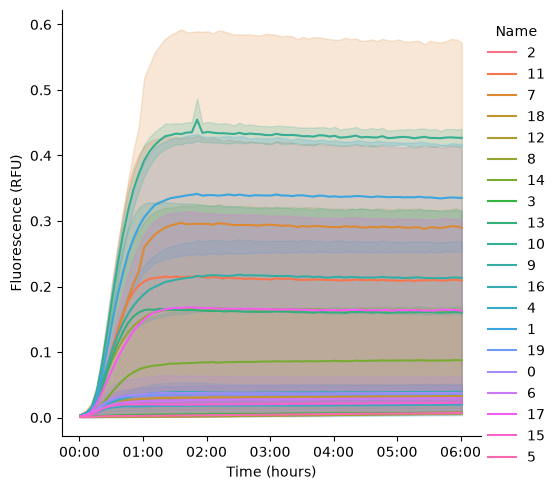

In [21]:
g = pr.plot_curves(data=data[data.Generator == "lhs"])

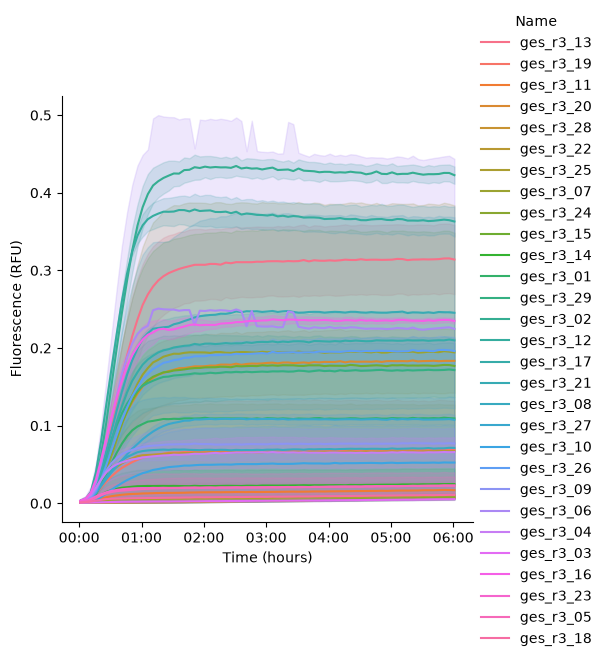

In [22]:
g = pr.plot_curves(data=data[data.Generator == "ges"])

,[ATP] mM,[Creatine phosphate] mM,[DNA] nM,[GTP] mM,[Magnesium acetate] mM,[PolyP] mM,[PPK] uM,[tRNA] ug/ul
292,2.01,20.12,2.04,2.01,8.05,16.86,1.37,3.37
293,2.01,20.12,2.04,2.01,8.05,16.86,1.37,3.37
294,2.01,20.12,2.04,2.01,8.05,16.86,1.37,3.37
295,2.01,20.12,2.04,2.01,8.05,16.86,1.37,3.37
296,2.01,20.12,2.04,2.01,8.05,16.86,1.37,3.37
...,...,...,...,...,...,...,...,...
8390,2.00,20.00,0.00,2.00,8.00,0.00,0.00,3.50
8391,2.00,20.00,0.00,2.00,8.00,0.00,0.00,3.50
8392,2.00,20.00,0.00,2.00,8.00,0.00,0.00,3.50
8393,2.00,20.00,0.00,2.00,8.00,0.00,0.00,3.50


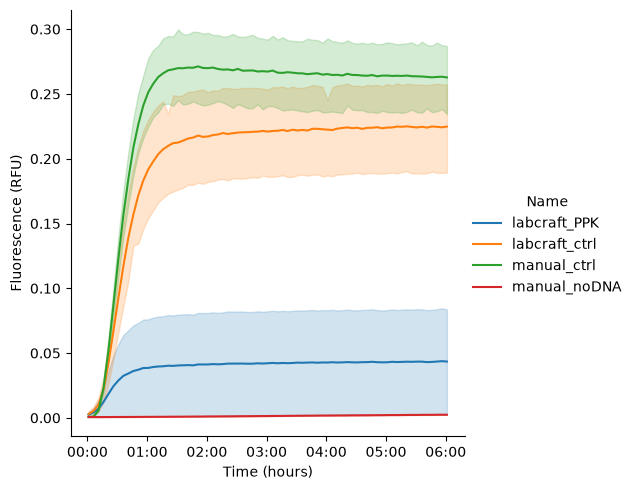

In [23]:
g = pr.plot_curves(data=data[data.Generator.isin(['manual', 'control'])])
data[data.Generator.isin(['manual', 'control'])][FACTOR_COLS]

## Kinetic Analysis
**Metrics extracted:**

  - **Vmax** (`Velocity Max`): Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level and time to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit

In [24]:
data.columns

Index(['Time', 'Well', 'Data', 'Row', 'Column', 'Read', 'Plate', 'Clock Time',
       'Generator', 'Type', 'Name', '[tRNA] ug/ul', '[Magnesium acetate] mM',
       '[Creatine phosphate] mM', '[ATP] mM', '[GTP] mM', '[PPK] uM',
       '[PolyP] mM', '[HEPES] mM', '[Potassium glutamate] mM', '[CTP] mM',
       '[UTP] mM', '[TCEP] mM', '[Folinic acid] mM', '[Spermidine] mM',
       '[aas] mM', '[RNAse Inhibitor] U/ml', '[Ribosome] uM', '[Pmix] mg/ml',
       '[DNA] nM', '[tRNA] ug/ul conc_to_add',
       '[tRNA] ug/ul vol_to_pipette_ul', '[Magnesium acetate] mM conc_to_add',
       '[Magnesium acetate] mM vol_to_pipette_ul',
       '[Creatine phosphate] mM conc_to_add',
       '[Creatine phosphate] mM vol_to_pipette_ul', '[ATP] mM conc_to_add',
       '[ATP] mM vol_to_pipette_ul', '[GTP] mM conc_to_add',
       '[GTP] mM vol_to_pipette_ul', '[PPK] uM conc_to_add',
       '[PPK] uM vol_to_pipette_ul', '[PolyP] mM conc_to_add',
       '[PolyP] mM vol_to_pipette_ul', '[DNA] nM conc_to_add',
 

In [25]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = pr.kinetic_analysis(
    data=data,
    group_by=['Well', 'Name', 'Type', *FACTOR_COLS],  # Group by experimental condition
)
# kinetics = kinetics.reset_index()
kinetics.head()

Velocity  \
                                                                                                                                                         Time   
Well Name         Type   [ATP] mM [Creatine phosphate] mM [DNA] nM [GTP] mM [Magnesium acetate] mM [PolyP] mM [PPK] uM [tRNA] ug/ul                             
E6   2            Sample 4.37     47.75                   2.27     4.09     31.43                  31.96      3.06     4.22         0 days 04:31:06.932930480   
E7   11           Sample 2.94     37.07                   2.11     5.92     55.89                  13.95      0.47     4.56         0 days 05:55:01.353671641   
E8   7            Sample 2.72     39.70                   2.25     5.82     17.29                  33.62      2.03     4.62         0 days 05:30:29.484582973   
E9   ges_r3_13    Sample 1.87     30.87                   1.89     1.87     23.34                  0.00       0.00     2.50         0 days 00:42:45.837078595   
E10  labcraft_PPK Sample 2.01     20.12                   2.04     2.01     8.05                   16.86      1.37     3.37         0 days 02:51:06.801462788   

                                                                                                                                                     \
                                                                                                                                    data_normalized   
Well Name         Type   [ATP] mM [Creatine phosphate] mM [DNA] nM [GTP] mM [Magnesium acetate] mM [PolyP] mM [PPK] uM [tRNA] ug/ul                   
E6   2            Sample 4.37     47.75                   2.27     4.09     31.43                  31.96      3.06     4.22                    0.01   
E7   11           Sample 2.94     37.07                   2.11     5.92     55.89                  13.95      0.47     4.56                    0.01   
E8   7            Sample 2.72     39.70                   2.25     5.82     17.29                  33.62      2.03     4.62                    0.01   
E9   ges_r3_13    Sample 1.87     30.87                   1.89     1.87     23.34                  0.00       0.00     2.50                    0.13   
E10  labcraft_PPK Sample 2.01     20.12                   2.04     2.01     8.05                   16.86      1.37     3.37                    0.00   

                                                                                                                                          \
                                                                                                                                     Max   
Well Name         Type   [ATP] mM [Creatine phosphate] mM [DNA] nM [GTP] mM [Magnesium acetate] mM [PolyP] mM [PPK] uM [tRNA] ug/ul        
E6   2            Sample 4.37     47.75                   2.27     4.09     31.43                  31.96      3.06     4.22         0.00   
E7   11           Sample 2.94     37.07                   2.11     5.92     55.89                  13.95      0.47     4.56         0.00   
E8   7            Sample 2.72     39.70                   2.25     5.82     17.29                  33.62      2.03     4.62         0.00   
E9   ges_r3_13    Sample 1.87     30.87                   1.89     1.87     23.34                  0.00       0.00     2.50         0.30   
E10  labcraft_PPK Sample 2.01     20.12                   2.04     2.01     8.05                   16.86      1.37     3.37         0.00   

                                                                                                                                                          Lag  \
                                                                                                                                                         Time   
Well Name         Type   [ATP] mM [Creatine phosphate] mM [DNA] nM [GTP] mM [Magnesium acetate] mM [PolyP] mM [PPK] uM [tRNA] ug/ul                             
E6   2            Sample 4.37     47.75        

In [26]:
kinetics

Velocity  \
                                                                                                                                                          Time   
Well Name         Type    [ATP] mM [Creatine phosphate] mM [DNA] nM [GTP] mM [Magnesium acetate] mM [PolyP] mM [PPK] uM [tRNA] ug/ul                             
E6   2            Sample  4.37     47.75                   2.27     4.09     31.43                  31.96      3.06     4.22         0 days 04:31:06.932930480   
E7   11           Sample  2.94     37.07                   2.11     5.92     55.89                  13.95      0.47     4.56         0 days 05:55:01.353671641   
E8   7            Sample  2.72     39.70                   2.25     5.82     17.29                  33.62      2.03     4.62         0 days 05:30:29.484582973   
E9   ges_r3_13    Sample  1.87     30.87                   1.89     1.87     23.34                  0.00       0.00     2.50         0 days 00:42:45.837078595   
E10  labcraft_PPK Sample  2.01     20.12                   2.04     2.01     8.05                   16.86      1.37     3.37         0 days 02:51:06.801462788   
...                                                                                                                                                        ...   
M13  manual_noDNA Control 2.00     20.00                   0.00     2.00     8.00                   0.00       0.00     3.50         0 days 04:36:06.984531007   
M14  manual_noDNA Control 2.00     20.00                   0.00     2.00     8.00                   0.00       0.00     3.50         0 days 04:01:06.949496467   
M15  manual_noDNA Control 2.00     20.00                   0.00     2.00     8.00                   0.00       0.00     3.50         0 days 03:01:06.870813823   
M16  manual_noDNA Control 2.00     20.00                   0.00     2.00     8.00                   0.00       0.00     3.50         0 days 05:31:07.006331676   
M17  manual_noDNA Control 2.00     20.00                   0.00     2.00     8.00                   0.00       0.00     3.50         0 days 03:51:06.934725932   

                                                                                                                                                      \
                                                                                                                                     data_normalized   
Well Name         Type    [ATP] mM [Creatine phosphate] mM [DNA] nM [GTP] mM [Magnesium acetate] mM [PolyP] mM [PPK] uM [tRNA] ug/ul                   
E6   2            Sample  4.37     47.75                   2.27     4.09     31.43                  31.96      3.06     4.22                    0.01   
E7   11           Sample  2.94     37.07                   2.11     5.92     55.89                  13.95      0.47     4.56                    0.01   
E8   7            Sample  2.72     39.70                   2.25     5.82     17.29                  33.62      2.03     4.62                    0.01   
E9   ges_r3_13    Sample  1.87     30.87                   1.89     1.87     23.34                  0.00       0.00     2.50                    0.13   
E10  labcraft_PPK Sample  2.01     20.12                   2.04     2.01     8.05                   16.86      1.37     3.37                    0.00   
...                                                                                                                                              ...   
M13  manual_noDNA Control 2.00     20.00                   0.00     2.00     8.00                   0.00       0.00     3.50                    0.00   
M14  manual_noDNA Control 2.00     20.00                   0.00     2.00     8.00                   0.00       0.00     3.50                    0.00   
M15  manual_noDNA Control 2.00     20.00                   0.00     2.00     8.00                   0.00       0.00     3.50                    0.00   
M16  manual_noDNA Control 2.00     20.00                 

## Visualize Fits on Individual Wells

In [27]:
# Plot kinetic fits 
# g = pr.plot_kinetics(data,  group_by=['Well', 'Name', *FACTOR_COLS])

In [28]:
# g = pr.plot_kinetics(data[data.Type=="Control"],  group_by=['Well', 'Name', *FACTOR_COLS])


In [29]:
# Which samples have 0?

## Summary Plots

In [30]:
# pr.plot_summary(data)

In [31]:
responses = ["steady_state", "vmax", "lag_time_min"]

kin = kinetics.reset_index()
kin.columns = [
    "_".join([str(x).replace(" ", "_") for x in col if x])
    for col in kin.columns
]
factors = [str(x).replace(" ", "_") for x in FACTOR_COLS]
kin.head()

,Well,Name,Type,[ATP]_mM,[Creatine_phosphate]_mM,[DNA]_nM,[GTP]_mM,[Magnesium_acetate]_mM,[PolyP]_mM,[PPK]_uM,...,Velocity_data_normalized,Velocity_Max,Lag_Time,Lag_data_normalized,Steady_State_Time,Steady_State_data_normalized,Fit_params,Fit_R^2,Fit_drift,Fit_good_fit
0,E6,2,Sample,4.37,47.75,2.27,4.09,31.43,31.96,3.06,...,0.01,0.00,0 days 02:30:50.518510192,0.00,0 days 07:28:11.078884232,0.01,"[0.012713766338364322, 0.9977254050484854, 4.5...",0.89,-0.00,False
1,E7,11,Sample,2.94,37.07,2.11,5.92,55.89,13.95,0.47,...,0.01,0.00,0 days 00:29:51.104754272,0.00,0 days 13:53:44.722373467,0.01,"[0.012090020783951569, 0.3690368088449321, 5.9...",1.00,0.00,True
2,E8,7,Sample,2.72,39.70,2.25,5.82,17.29,33.62,2.03,...,0.01,0.00,0 days 00:03:52.096342456,0.00,0 days 13:31:21.141494155,0.01,"[0.011863968727897852, 0.36739589541185114, 5....",1.00,0.00,True
3,E9,ges_r3_13,Sample,1.87,30.87,1.89,1.87,23.34,0.00,0.00,...,0.13,0.30,0 days 00:15:32.077890003,0.02,0 days 01:22:51.089196450,0.25,"[0.26784790332378383, 4.407014236186926, 0.712...",1.00,0.00,True
4,E10,labcraft_PPK,Sample,2.01,20.12,2.04,2.01,8.05,16.86,1.37,...,0.00,0.00,0 days 00:38:01.899864715,0.00,0 days 06:07:02.329216716,0.00,"[0.003429207162429867, 0.9017017820792528, 2.8...",0.99,-0.00,True


In [32]:
kin.columns

Index(['Well', 'Name', 'Type', '[ATP]_mM', '[Creatine_phosphate]_mM',
       '[DNA]_nM', '[GTP]_mM', '[Magnesium_acetate]_mM', '[PolyP]_mM',
       '[PPK]_uM', '[tRNA]_ug/ul', 'Velocity_Time', 'Velocity_data_normalized',
       'Velocity_Max', 'Lag_Time', 'Lag_data_normalized', 'Steady_State_Time',
       'Steady_State_data_normalized', 'Fit_params', 'Fit_R^2', 'Fit_drift',
       'Fit_good_fit'],
      dtype='object')

In [33]:
from plate_qc import (
        qc_summary, plot_replicate_agreement,
        plot_plate_heatmap, plot_qc_overview,
    )
responses = ['Steady_State_data_normalized', 'Velocity_Max']

In [34]:
clean, failed = qc_summary(kin, factors, responses)

DOE QC Summary
  Total wells:  115
  Good fits:    85 (73.9%)
  Failed fits:  30 (26.1%)

  R² < 0:       0
  0 ≤ R² < 0.9: 27

  Response metrics (good fits only):
    Steady_State_data_normalized    min=0.0026  median=0.1285  max=0.5510
    Velocity_Max                    min=0.0004  median=0.1772  max=0.8047

  Factor ranges for FAILED wells:
    [ATP]_mM                        [1.992 – 6.192]
    [Creatine_phosphate]_mM         [20.000 – 78.425]
    [DNA]_nM                        [0.000 – 2.270]
    [GTP]_mM                        [1.992 – 5.011]
    [Magnesium_acetate]_mM          [7.967 – 115.116]
    [PolyP]_mM                      [0.000 – 33.700]
    [PPK]_uM                        [0.000 – 4.450]
    [tRNA]_ug/ul                    [2.651 – 5.080]


In [35]:
kin.head()

,Well,Name,Type,[ATP]_mM,[Creatine_phosphate]_mM,[DNA]_nM,[GTP]_mM,[Magnesium_acetate]_mM,[PolyP]_mM,[PPK]_uM,...,Velocity_data_normalized,Velocity_Max,Lag_Time,Lag_data_normalized,Steady_State_Time,Steady_State_data_normalized,Fit_params,Fit_R^2,Fit_drift,Fit_good_fit
0,E6,2,Sample,4.37,47.75,2.27,4.09,31.43,31.96,3.06,...,0.01,0.00,0 days 02:30:50.518510192,0.00,0 days 07:28:11.078884232,0.01,"[0.012713766338364322, 0.9977254050484854, 4.5...",0.89,-0.00,False
1,E7,11,Sample,2.94,37.07,2.11,5.92,55.89,13.95,0.47,...,0.01,0.00,0 days 00:29:51.104754272,0.00,0 days 13:53:44.722373467,0.01,"[0.012090020783951569, 0.3690368088449321, 5.9...",1.00,0.00,True
2,E8,7,Sample,2.72,39.70,2.25,5.82,17.29,33.62,2.03,...,0.01,0.00,0 days 00:03:52.096342456,0.00,0 days 13:31:21.141494155,0.01,"[0.011863968727897852, 0.36739589541185114, 5....",1.00,0.00,True
3,E9,ges_r3_13,Sample,1.87,30.87,1.89,1.87,23.34,0.00,0.00,...,0.13,0.30,0 days 00:15:32.077890003,0.02,0 days 01:22:51.089196450,0.25,"[0.26784790332378383, 4.407014236186926, 0.712...",1.00,0.00,True
4,E10,labcraft_PPK,Sample,2.01,20.12,2.04,2.01,8.05,16.86,1.37,...,0.00,0.00,0 days 00:38:01.899864715,0.00,0 days 06:07:02.329216716,0.00,"[0.003429207162429867, 0.9017017820792528, 2.8...",0.99,-0.00,True


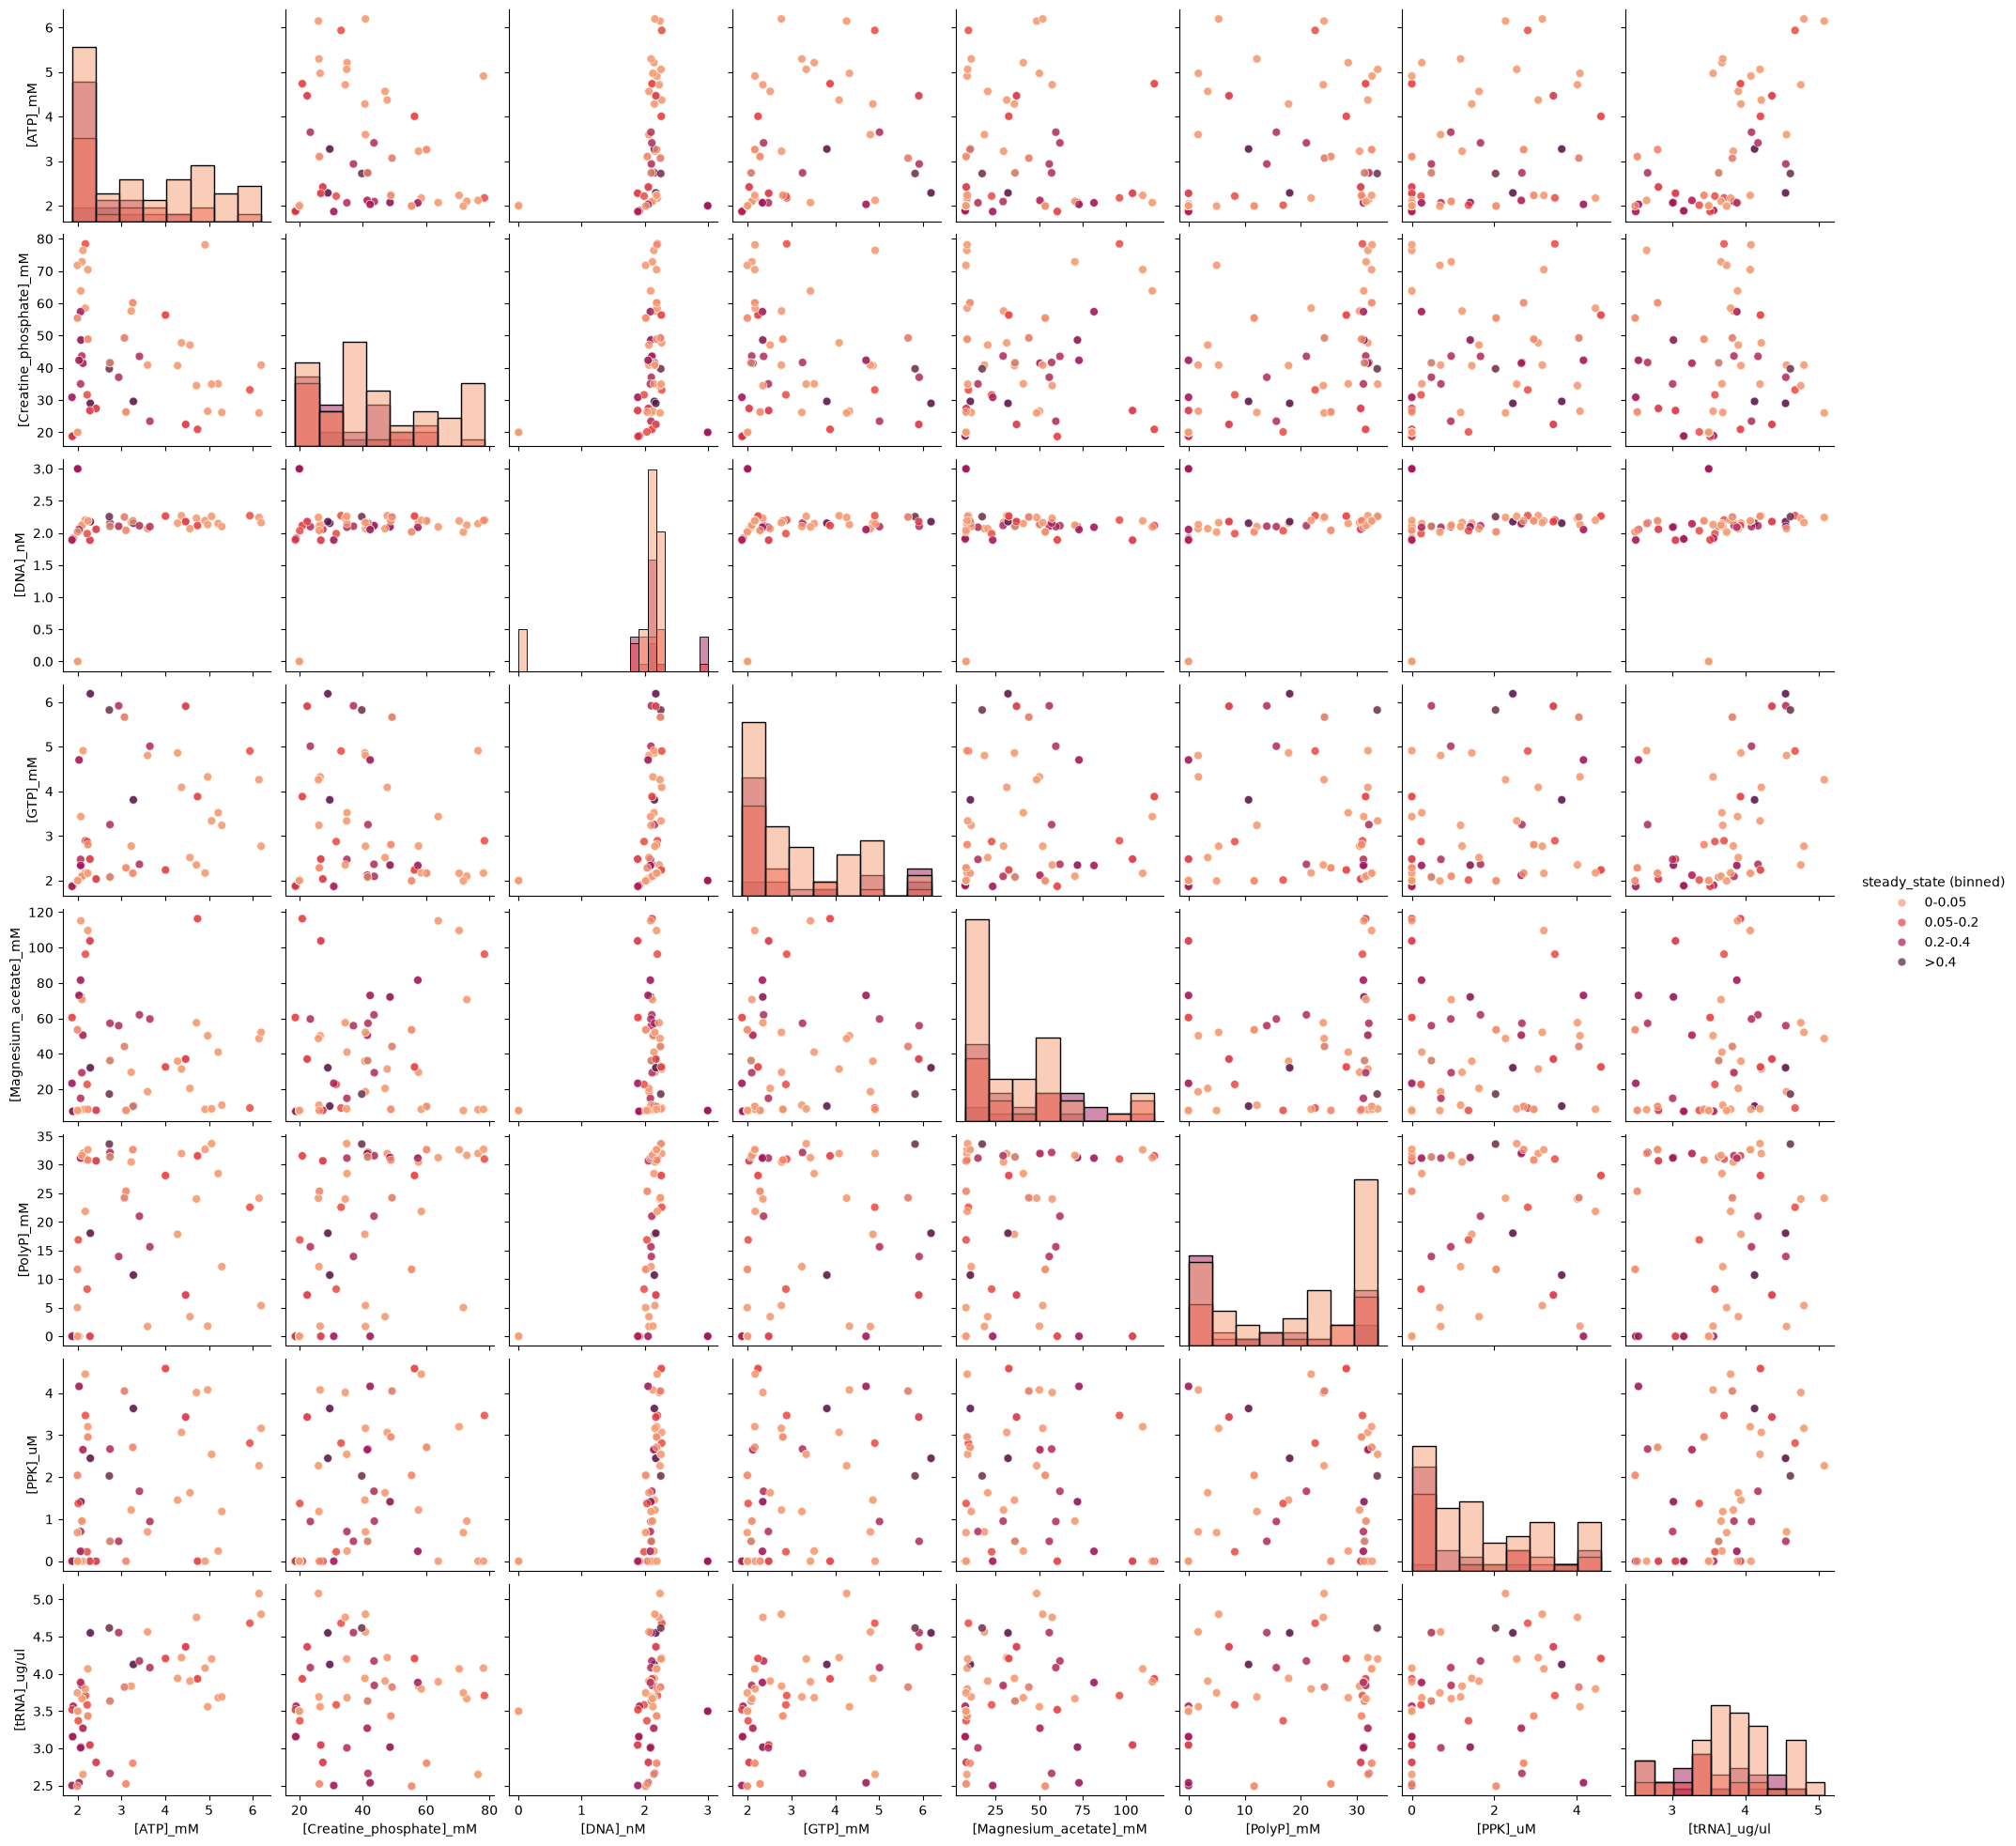

In [36]:
import seaborn as sns
kin['steady_state (binned)'] = pd.cut(                                                                                                                                                                                   
  kin['Steady_State_data_normalized'],                                                                                                                                                                        
  bins=[0, 0.05, .2, 0.4, 1.0],
  labels=['0-0.05', '0.05-0.2', '0.2-0.4', '>0.4']
)                                                                                                                                                                                                               
# val = "Steady_State_data_normalized"
val = 'steady_state (binned)'
g = sns.pairplot(
  kin[factors + [val]],
  vars=factors,
  hue=val,
  palette ="rocket_r",
  # palette={'0-0.05': '#d9534f', '0.05-0.2': 'orange', '>0.2': 'blue'},
  plot_kws={'alpha': 0.7, 's': 40},
  diag_kind='hist',
)